In [1]:
from sklearn.cross_decomposition import CCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler

## Data loading and preprocessing 

In [2]:
HR = pd.read_csv(f'data'+'\HR_data.csv')
type(HR)
HR

id = HR.iloc[:, -16:-10]
id.pop('Frustrated')

X = HR.iloc[:,:-10]

y = HR.iloc[:,-16:]
y = y.drop(columns=['Round', 'Phase', 'Individual', 'Puzzler', 'Cohort'])
X  = X.drop(columns=['Round', 'Phase', 'Individual', 'Puzzler', 'Cohort', 'Frustrated'])
print(X.shape, y.shape)

EMOTION_COLS = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired',
    'nervous', 'attentive', 'afraid', 'active', 'determined'
]

#Imput median
imputer = SimpleImputer(strategy="median")
Xf = imputer.fit_transform(X)
yf = imputer.fit_transform(y)

#Scalers
scaler_X = StandardScaler()
scaler_Y = RobustScaler()

Xf = scaler_X.fit_transform(Xf)
yf = scaler_Y.fit_transform(yf)

print(f"X shape: {Xf.shape}")
print(f"Y shape: {yf.shape}")
print(f"X scaled stats: min={Xf.min():.3f}, max={Xf.max():.3f}")
print(f"Y scaled stats: min={yf.min():.3f}, max={yf.max():.3f}")
y

(312, 52) (312, 11)
X shape: (312, 52)
Y shape: (312, 11)
X scaled stats: min=-13.266, max=12.112
Y scaled stats: min=-1.000, max=3.000


,Frustrated,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,3.0,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,2.0,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,2.0,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,2.0,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
307,7.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0
308,2.0,2.0,1.0,3.0,1.0,1.0,1.0,4.0,1.0,3.0,4.0
309,2.0,1.0,1.0,3.0,1.0,3.0,1.0,3.0,1.0,3.0,4.0
310,3.0,2.0,1.0,3.0,1.0,3.0,1.0,4.0,1.0,4.0,4.0


## Optimal number of components for PLS (original feutures)

  n=1: RMSE=0.5970, ExplVar=0.0287, R2=0.0091
  n=2: RMSE=0.5871, ExplVar=0.0414, R2=0.0211
  n=3: RMSE=0.5875, ExplVar=0.0368, R2=0.0159
  n=4: RMSE=0.5871, ExplVar=0.0364, R2=0.0144
  n=5: RMSE=0.5921, ExplVar=0.0213, R2=-0.0015
  n=6: RMSE=0.5952, ExplVar=0.0120, R2=-0.0079
  n=7: RMSE=0.5988, ExplVar=-0.0006, R2=-0.0217
  n=8: RMSE=0.6013, ExplVar=-0.0100, R2=-0.0319

Optimal n of components RMSE: 2
Optimal n of components Expl.Var: 2
Optimal n of components R2: 2


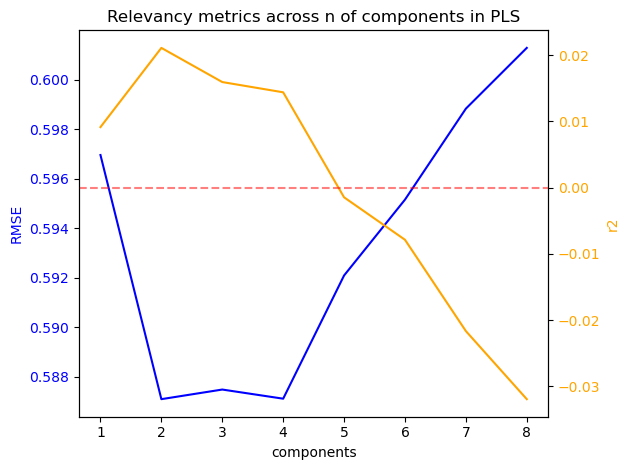

In [3]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.cross_decomposition import PLSCanonical
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, explained_variance_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_cv = []
expl_var = []
r_2 = []

n_components = np.arange(1, 9)

for k in n_components:
    pls = PLSRegression(n_components=k)
    
    # manual CV 
    fold_rmse = []
    fold_var = []
    fold_r2 = []
    
    for train_idx, test_idx in kf.split(Xf):
        X_train, X_test = Xf[train_idx], Xf[test_idx]
        Y_train, Y_test = yf[train_idx], yf[test_idx]
        pls.fit(X_train, Y_train)
        Y_pred = pls.predict(X_test)
        
        fold_rmse.append(np.sqrt(mean_squared_error(Y_test, Y_pred)))
        fold_var.append(explained_variance_score(Y_test, Y_pred, multioutput='uniform_average'))
        fold_r2.append(r2_score(Y_test, Y_pred, multioutput='uniform_average'))
    
    rmse_cv.append(np.mean(fold_rmse))
    expl_var.append(np.mean(fold_var))
    r_2.append(np.mean(fold_r2))
    print(f"  n={k}: RMSE={rmse_cv[-1]:.4f}, ExplVar={expl_var[-1]:.4f}, R2={r_2[-1]:.4f}")

best_k_rmse = n_components[np.argmin(rmse_cv)]
best_k_var  = n_components[np.argmax(expl_var)]
best_k_r2   = n_components[np.argmax(r_2)]
print(f"\nOptimal n of components RMSE: {best_k_rmse}")
print(f"Optimal n of components Expl.Var: {best_k_var}")
print(f"Optimal n of components R2: {best_k_r2}")

fig, ax1 = plt.subplots()
ax1.set_xlabel("components")
ax1.set_ylabel("RMSE", color="blue")
ax1.plot(n_components, rmse_cv, label="RMSE", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

ax2 = ax1.twinx()
ax2.set_ylabel("r2", color="orange")
ax2.plot(n_components, r_2, label="r2", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='R2=0')

plt.title("Relevancy metrics across n of components in PLS")
fig.tight_layout()
plt.show()

# Fit final model on full data — n=2 optimal
pls_final = PLSRegression(n_components=2)
pls_final.fit(Xf, yf)
Xpls, ypls = pls_final.transform(Xf, yf)

## Original X and Y loadings.

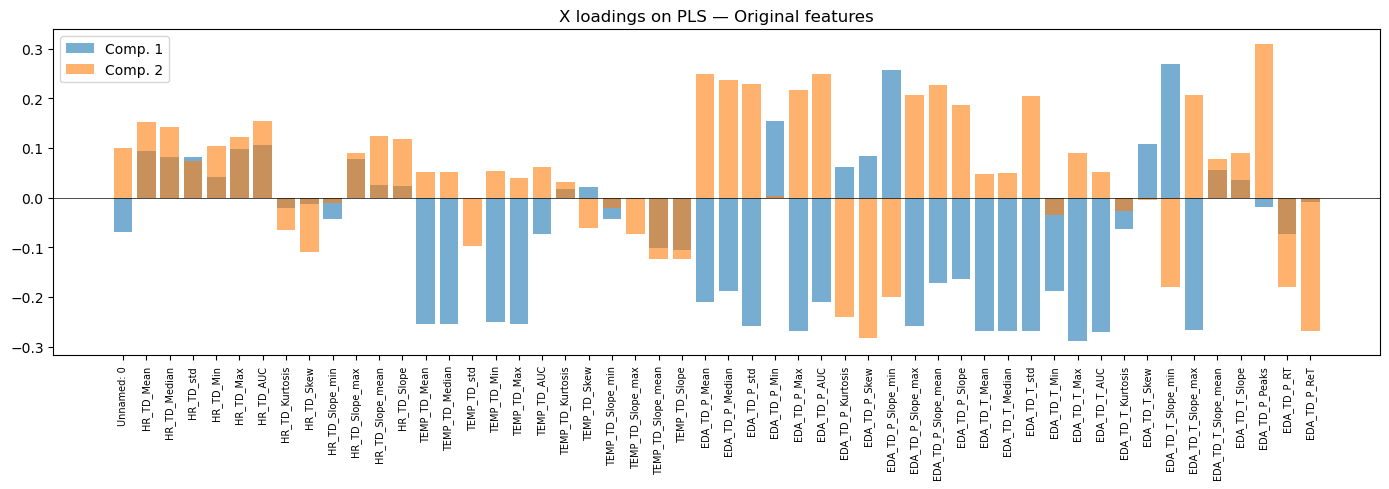

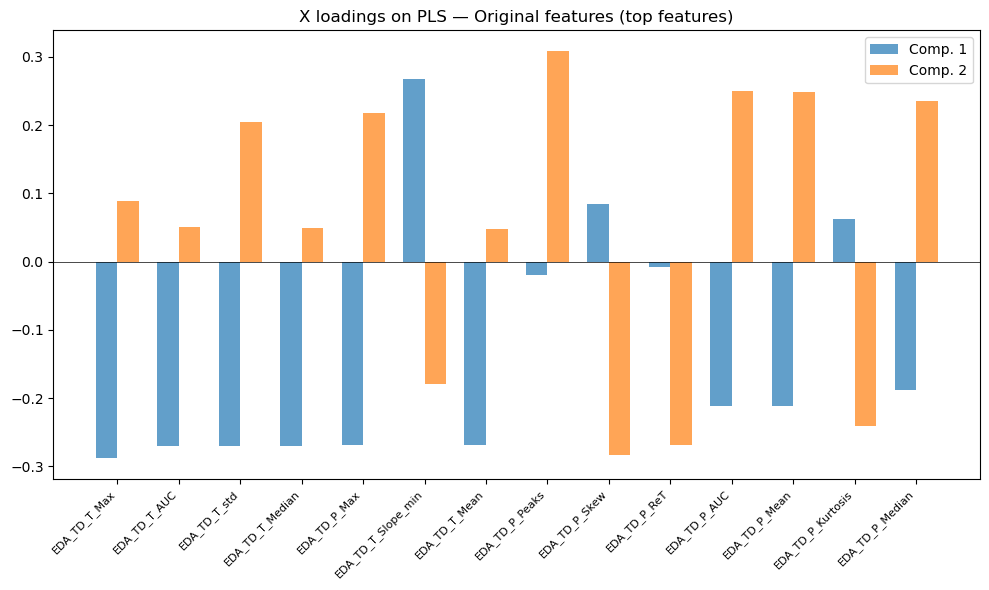

In [4]:
# X loadings original features
fig, ax = plt.subplots(figsize=(14, 5))
x_cols = list(X.columns)
ax.bar(range(len(pls.x_loadings_)), pls.x_loadings_[:, 0], alpha=0.6, label='Comp. 1')
ax.bar(range(len(pls.x_loadings_)), pls.x_loadings_[:, 1], alpha=0.6, label='Comp. 2')
ax.set_xticks(range(len(x_cols)))
ax.set_xticklabels(x_cols, rotation=90, fontsize=7)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.title('X loadings on PLS — Original features')
plt.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

x_load1 = pd.Series(pls.x_loadings_[:, 0], index=list(X.columns))
x_load2 = pd.Series(pls.x_loadings_[:, 1], index=list(X.columns))

top7_1 = x_load1.abs().sort_values(ascending=False).head(7).index
top7_2 = x_load2.abs().sort_values(ascending=False).head(7).index


combined = list(dict.fromkeys(list(top7_1) + list(top7_2)))

vals1 = x_load1[combined]
vals2 = x_load2[combined]

x = np.arange(len(combined))
width = 0.35

ax.bar(x - width/2, vals1, width, alpha=0.7, label='Comp. 1',)
ax.bar(x + width/2, vals2, width, alpha=0.7, label='Comp. 2')
ax.set_xticks(x)
ax.set_xticklabels(combined, rotation=45, ha='right', fontsize=8)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('X loadings on PLS — Original features (top features)')
ax.legend()
plt.tight_layout()
plt.show()

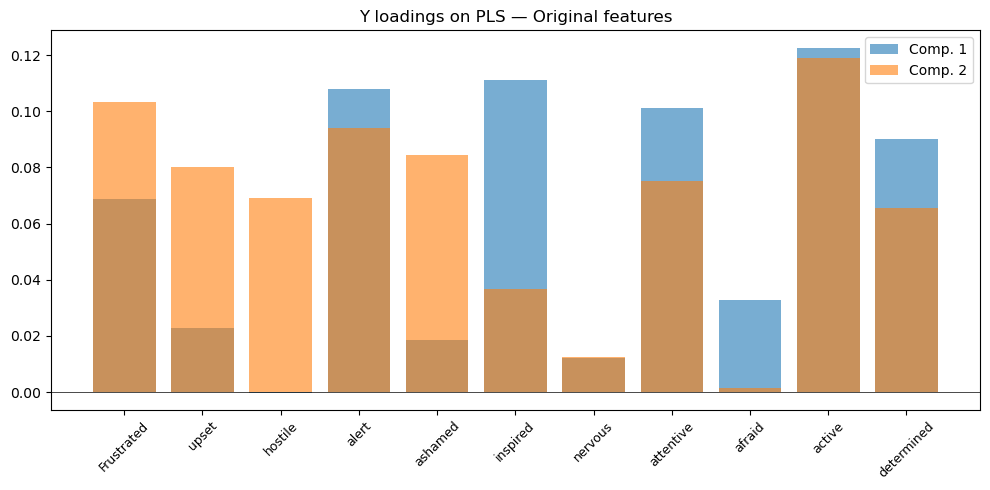

In [5]:
# Y loadings — original features
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(pls.y_loadings_)), pls.y_loadings_[:, 0], alpha=0.6, label='Comp. 1')
ax.bar(range(len(pls.y_loadings_)), pls.y_loadings_[:, 1], alpha=0.6, label='Comp. 2')
ax.set_xticks(range(len(EMOTION_COLS)))
ax.set_xticklabels(EMOTION_COLS, rotation=45, fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.title('Y loadings on PLS — Original features')
plt.legend()
plt.tight_layout()
plt.show()

## PLS on Temporal feutures dataset
##### (same steps on our created Temporal dataset)

X shape: (312, 18)
Y shape: (312, 11)
X scaled stats: min=-10.581, max=8.740
Y scaled stats: min=-1.000, max=3.000
  n=1: RMSE=0.5916, ExplVar=0.0403, R2=0.0204
  n=2: RMSE=0.5901, ExplVar=0.0399, R2=0.0188
  n=3: RMSE=0.5941, ExplVar=0.0271, R2=0.0048
  n=4: RMSE=0.5947, ExplVar=0.0248, R2=0.0024
  n=5: RMSE=0.5978, ExplVar=0.0155, R2=-0.0084
  n=6: RMSE=0.5996, ExplVar=0.0086, R2=-0.0148
  n=7: RMSE=0.6007, ExplVar=0.0065, R2=-0.0168
  n=8: RMSE=0.5986, ExplVar=0.0081, R2=-0.0154

Optimal n of components R2: 1


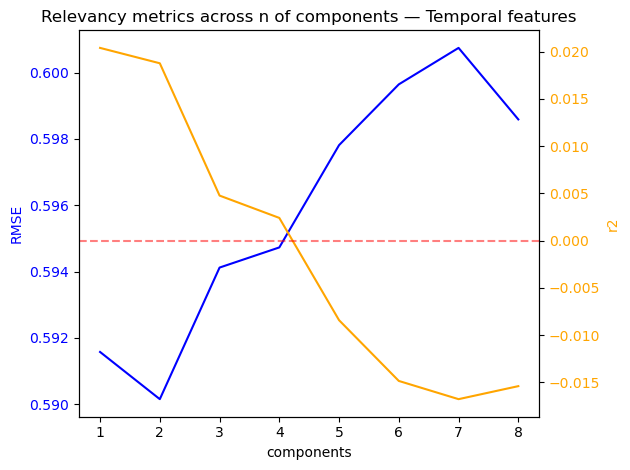

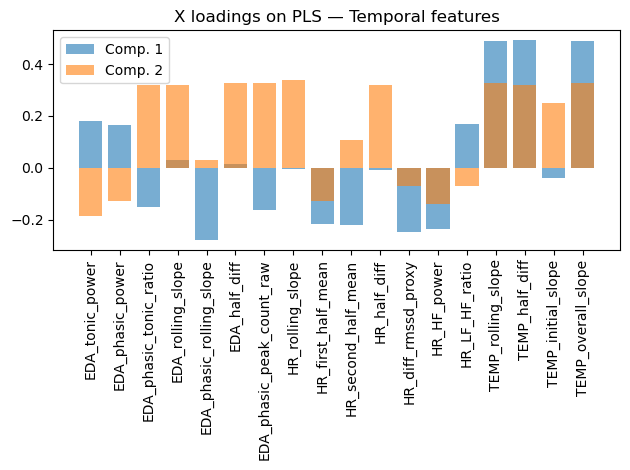

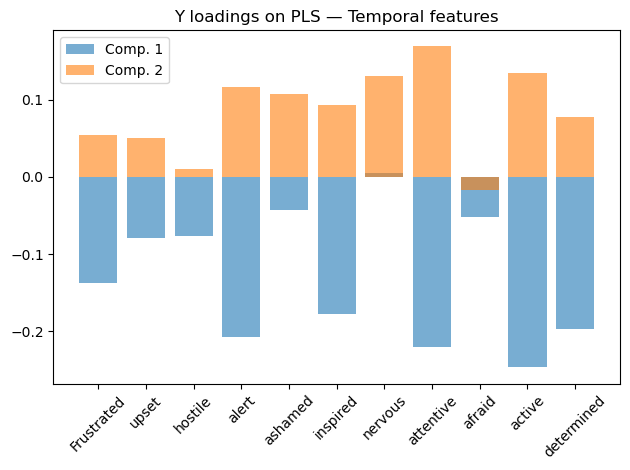

COMPARISON SUMMARY
Original features  (52 features): best CV R2 = 0.0211 (n=2)
Temporal features  (20 features): best CV R2 = 0.0204 (n=1)

Original features:
  Component 1: r = 0.2629
  Component 2: r = 0.2485

Temporal features:
  Component 1: r = 0.3776
  Component 2: r = 0.2281


In [6]:
# PLS ON TEMPORAL FEATURES — same methodology as original features above

# Load temporal features
df_temporal = pd.read_csv("features_temporal.csv")

#  columns
BIO_COLS_TEMPORAL = [
    # EDA (7) 
    'EDA_tonic_power', 'EDA_phasic_power', 'EDA_phasic_tonic_ratio',
    'EDA_rolling_slope', 'EDA_phasic_rolling_slope',
    'EDA_half_diff', 'EDA_phasic_peak_count_raw',

    # HR (7)
    'HR_rolling_slope', 'HR_first_half_mean', 'HR_second_half_mean',
    'HR_half_diff', 'HR_diff_rmssd_proxy',
    'HR_HF_power', 'HR_LF_HF_ratio',

    # TEMP (4) 
    'TEMP_rolling_slope', 'TEMP_half_diff',
    'TEMP_initial_slope', 'TEMP_overall_slope'
]

EMOTION_COLS = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired',
    'nervous', 'attentive', 'afraid', 'active', 'determined'
]

# Extract X and Y
X_temp = df_temporal[BIO_COLS_TEMPORAL]
y_temp = df_temporal[EMOTION_COLS]

# Impute with median
imputer_X2 = SimpleImputer(strategy="median")
imputer_Y2 = SimpleImputer(strategy="median")

Xf_temp = imputer_X2.fit_transform(X_temp)
yf_temp = imputer_Y2.fit_transform(y_temp)

# Log transform power features 
power_idx = [BIO_COLS_TEMPORAL.index(c) for c in 
             ['EDA_tonic_power', 'EDA_phasic_power', 'HR_HF_power']]
for idx in power_idx:
    Xf_temp[:, idx] = np.log1p(Xf_temp[:, idx])

# Scale same as original features
scaler_X2 = StandardScaler()
scaler_Y2 = RobustScaler()

Xf_temp = scaler_X2.fit_transform(Xf_temp)
yf_temp = scaler_Y2.fit_transform(yf_temp)

print(f"X shape: {Xf_temp.shape}")
print(f"Y shape: {yf_temp.shape}")
print(f"X scaled stats: min={Xf_temp.min():.3f}, max={Xf_temp.max():.3f}")
print(f"Y scaled stats: min={yf_temp.min():.3f}, max={yf_temp.max():.3f}")

# CV
kf2 = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_cv2 = []
expl_var2 = []
r_2_2 = []

n_components2 = np.arange(1, 9)

for k in n_components2:
    pls2 = PLSRegression(n_components=k)
    fold_rmse = []
    fold_var = []
    fold_r2 = []

    for train_idx, test_idx in kf2.split(Xf_temp):
        X_train, X_test = Xf_temp[train_idx], Xf_temp[test_idx]
        Y_train, Y_test = yf_temp[train_idx], yf_temp[test_idx]
        pls2.fit(X_train, Y_train)
        Y_pred = pls2.predict(X_test)
        fold_rmse.append(np.sqrt(mean_squared_error(Y_test, Y_pred)))
        fold_var.append(explained_variance_score(Y_test, Y_pred, multioutput='uniform_average'))
        fold_r2.append(r2_score(Y_test, Y_pred, multioutput='uniform_average'))

    rmse_cv2.append(np.mean(fold_rmse))
    expl_var2.append(np.mean(fold_var))
    r_2_2.append(np.mean(fold_r2))
    print(f"  n={k}: RMSE={rmse_cv2[-1]:.4f}, ExplVar={expl_var2[-1]:.4f}, R2={r_2_2[-1]:.4f}")

best_k_r2_2 = n_components2[np.argmax(r_2_2)]
print(f"\nOptimal n of components R2: {best_k_r2_2}")

# Plots for best n
fig, ax1 = plt.subplots()
ax1.set_xlabel("components")
ax1.set_ylabel("RMSE", color="blue")
ax1.plot(n_components2, rmse_cv2, label="RMSE", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax2 = ax1.twinx()
ax2.set_ylabel("r2", color="orange")
ax2.plot(n_components2, r_2_2, label="r2", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='R2=0')
plt.title("Relevancy metrics across n of components — Temporal features")
fig.tight_layout()
plt.show()

# Fit final model 
best_n_temp = 2
pls_temp = PLSRegression(n_components=best_n_temp)
pls_temp.fit(Xf_temp, yf_temp)
Xpls_temp, ypls_temp = pls_temp.transform(Xf_temp, yf_temp)



#Components Loadings plots
fig, ax = plt.subplots()
ax.bar(range(len(pls_temp.x_loadings_)), pls_temp.x_loadings_[:, 0], 
       alpha=0.6, label='Comp. 1')
if best_n_temp >= 2:
    ax.bar(range(len(pls_temp.x_loadings_)), pls_temp.x_loadings_[:, 1], 
           alpha=0.6, label='Comp. 2')
plt.xticks(range(len(BIO_COLS_TEMPORAL)), BIO_COLS_TEMPORAL, rotation=90)
plt.title('X loadings on PLS — Temporal features')
plt.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.bar(range(len(pls_temp.y_loadings_)), pls_temp.y_loadings_[:, 0], 
       alpha=0.6, label='Comp. 1')
if best_n_temp >= 2:
    ax.bar(range(len(pls_temp.y_loadings_)), pls_temp.y_loadings_[:, 1], 
           alpha=0.6, label='Comp. 2')
plt.xticks(range(len(EMOTION_COLS)), EMOTION_COLS, rotation=45)
plt.title('Y loadings on PLS — Temporal features')
plt.legend()
plt.tight_layout()
plt.show()

# Comparison summary 
print("COMPARISON SUMMARY")
print(f"Original features  (52 features): best CV R2 = {max(r_2):.4f} (n={n_components[np.argmax(r_2)]})")
print(f"Temporal features  (20 features): best CV R2 = {max(r_2_2):.4f} (n={best_k_r2_2})")


# Make sure these are defined from the final fitted models
Xpls, ypls = pls_final.transform(Xf, yf)
Xpls_temp, ypls_temp = pls_temp.transform(Xf_temp, yf_temp)

print("\nOriginal features:")
for comp in range(2):
    corr = np.corrcoef(Xpls[:, comp], ypls[:, comp])[0, 1]
    print(f"  Component {comp+1}: r = {corr:.4f}")


print("\nTemporal features:")
for comp in range(2):
    corr = np.corrcoef(Xpls_temp[:, comp], ypls_temp[:, comp])[0, 1]
    print(f"  Component {comp+1}: r = {corr:.4f}")

## Phase distribution by PLS for each component of each dataset.

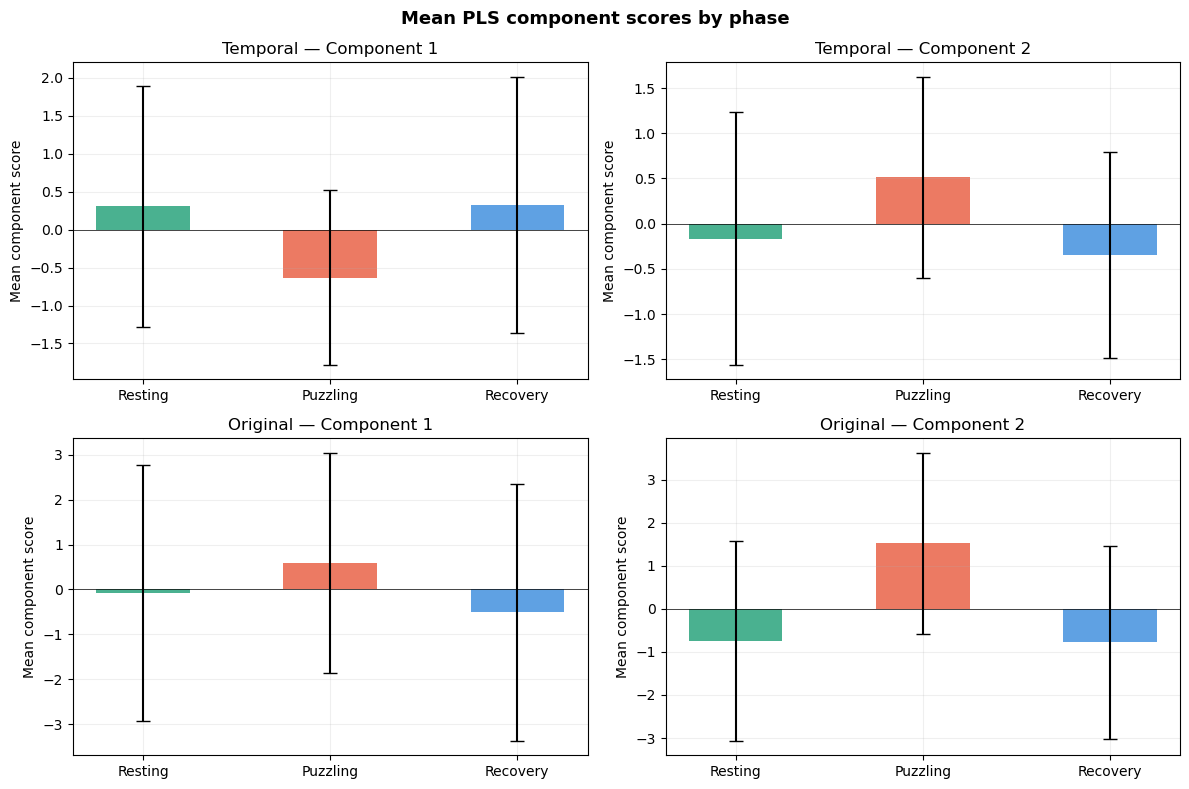

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


datasets = {
    'Temporal': Xpls_temp,
    'Original': Xpls
}

phase_labels = df_temporal['Phase'].values
colors = {'phase1': '#1D9E75', 'phase2': '#E8593C', 'phase3': '#378ADD'}
names  = {'phase1': 'Resting', 'phase2': 'Puzzling', 'phase3': 'Recovery'}

for row, (dataset_name, scores) in enumerate(datasets.items()):
    for comp in range(2):
        ax = axes[row, comp]
        
        comp_scores = scores[:, comp]
        
        # Mean score per phase
        means = []
        stds  = []
        phase_list = ['phase1', 'phase2', 'phase3']
        
        for phase in phase_list:
            mask = phase_labels == phase
            means.append(np.mean(comp_scores[mask]))
            stds.append(np.std(comp_scores[mask]))
        
        x = np.arange(3)
        bars = ax.bar(x, means, 
                      color=[colors[p] for p in phase_list],
                      alpha=0.8, width=0.5)
        ax.errorbar(x, means, yerr=stds, fmt='none', 
                    color='black', capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels([names[p] for p in phase_list])
        ax.set_ylabel('Mean component score')
        ax.set_title(f'{dataset_name} — Component {comp+1}')
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.grid(True, alpha=0.2)

plt.suptitle('Mean PLS component scores by phase', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_scores_by_component.png', dpi=150)
plt.show()